# 09: 包括的分析 — プロンプト構造 + 層別比較 + 混成debate設計

## Notebook 07-08の結論
- **同一モデル3コピー**: エージェント分離なし (silhouette=-0.017), ラウンド変化なし (p=1.0)
- **異なるモデル**: 全体分離は弱い (silhouette=0.047) が、**プロンプト種類で分離あり** (silhouette=0.108)
- **説明系プロンプト (P3/P4/P6)** でモデル間距離比 > 1.4

## 本ノートブックの3つの分析
- **Part A**: プロンプト種類別のhidden state構造（確定的→創作のスペクトル）
- **Part B**: 層別比較（浅い層→深い層でモデル間差異はどう変化するか）
- **Part C**: 混成debate（0.6B + 4B）でhidden state分離を検証

## データ
- Part A/B: リポジトリ同梱 (`data/platform_baseline/`, `data/platform_layer/`)
- Part C: GPUサーバーでのデータ収集後に実行

In [1]:
# === Cell 1: セットアップ ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    if not os.path.exists('thoughtcomm'):
        !git clone https://github.com/AUMEZAK/thoughtcomm.git
    %cd thoughtcomm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy import stats

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

BASELINE_DIR = 'data/platform_baseline/'
LAYER_DIR = 'data/platform_layer/'

PROMPTS = {
    'P1': {'text': '1+1', 'category': 'factual', 'expected': 'minimal'},
    'P2': {'text': 'Japan capital', 'category': 'knowledge', 'expected': 'small'},
    'P3': {'text': 'Photosynthesis', 'category': 'explanation', 'expected': 'medium'},
    'P4': {'text': 'Cat vs Dog', 'category': 'opinion', 'expected': 'large'},
    'P5': {'text': 'Haiku', 'category': 'creative', 'expected': 'maximum'},
    'P6': {'text': 'Quantum', 'category': 'technical', 'expected': 'medium-large'},
}
CATEGORY_ORDER = ['factual', 'knowledge', 'explanation', 'opinion', 'technical', 'creative']
MODELS = {'qwen3-0.6b': 1024, 'qwen3-4b': 2560}
DROP_COLS = ['trial_id', 'segment_index', 'segment_position']

print('Setup done.')

Cloning into 'thoughtcomm'...
remote: Enumerating objects: 468, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 468 (delta 33), reused 77 (delta 15), pack-reused 357 (from 1)
Receiving objects: 100% (468/468), 35.81 MiB | 13.58 MiB/s, done.
Resolving deltas: 100% (238/238), done.
/content/thoughtcomm
Setup done.


---
# Part A: プロンプト種類別のHidden State構造

**問い**: タスクの性質（確定的事実→創作）はhidden stateにどう反映されるか？

**指標**:
- trial間分散（同一プロンプトの10回の揺らぎ）
- segment間分散（生成過程での変化）
- PCA有効次元数（表現の複雑さ）
- モデル間距離比（0.6B vs 4Bの「考え方」の違い）

In [2]:
# === Cell 2: Part A — データ読み込み + 基本統計 ===
data = {}
for pid in PROMPTS:
    for mid in MODELS:
        path = os.path.join(BASELINE_DIR, f'{pid}_{mid}', 'segments.csv.gz')
        if os.path.exists(path):
            data[(pid, mid)] = pd.read_csv(path, compression='gzip')

print(f'Loaded: {len(data)} datasets')

# プロンプト × モデル別の統計
print(f'\n{"Prompt":8s} {"Model":15s} {"Mean":>8s} {"Std":>8s} {"Kurtosis":>10s} {"EffDim95":>10s}')
print('-' * 65)

prompt_stats = []
for pid in PROMPTS:
    for mid in MODELS:
        if (pid, mid) not in data:
            continue
        X = data[(pid, mid)].drop(columns=DROP_COLS).values
        flat = X.flatten()
        kurt = stats.kurtosis(flat[:100000])

        # PCA有効次元
        pca = PCA(n_components=min(X.shape))
        pca.fit(X - X.mean(axis=0))
        cumvar = np.cumsum(pca.explained_variance_ratio_)
        eff_dim = np.searchsorted(cumvar, 0.95) + 1

        row = {
            'pid': pid, 'mid': mid, 'category': PROMPTS[pid]['category'],
            'mean': float(X.mean()), 'std': float(X.std()),
            'kurtosis': float(kurt), 'eff_dim_95': int(eff_dim),
        }
        prompt_stats.append(row)
        print(f'{pid:8s} {mid:15s} {row["mean"]:8.3f} {row["std"]:8.3f} '
              f'{row["kurtosis"]:10.2f} {row["eff_dim_95"]:10d}')

Loaded: 12 datasets

Prompt   Model               Mean      Std   Kurtosis   EffDim95
-----------------------------------------------------------------
P1       qwen3-0.6b         0.049    3.257     114.87         15
P1       qwen3-4b          -0.065    3.185     399.29         32
P2       qwen3-0.6b         0.089    3.662     150.27         18
P2       qwen3-4b          -0.036    2.966     434.30         23
P3       qwen3-0.6b         0.213    4.298     151.68         39
P3       qwen3-4b          -0.104    3.364     405.93         39
P4       qwen3-0.6b         0.167    3.984     176.32         28
P4       qwen3-4b          -0.073    3.229     416.73         37
P5       qwen3-0.6b         0.076    3.647     174.10         19
P5       qwen3-4b          -0.087    3.193     372.83         46
P6       qwen3-0.6b         0.182    4.183     165.97         36
P6       qwen3-4b          -0.071    3.356     418.35         38


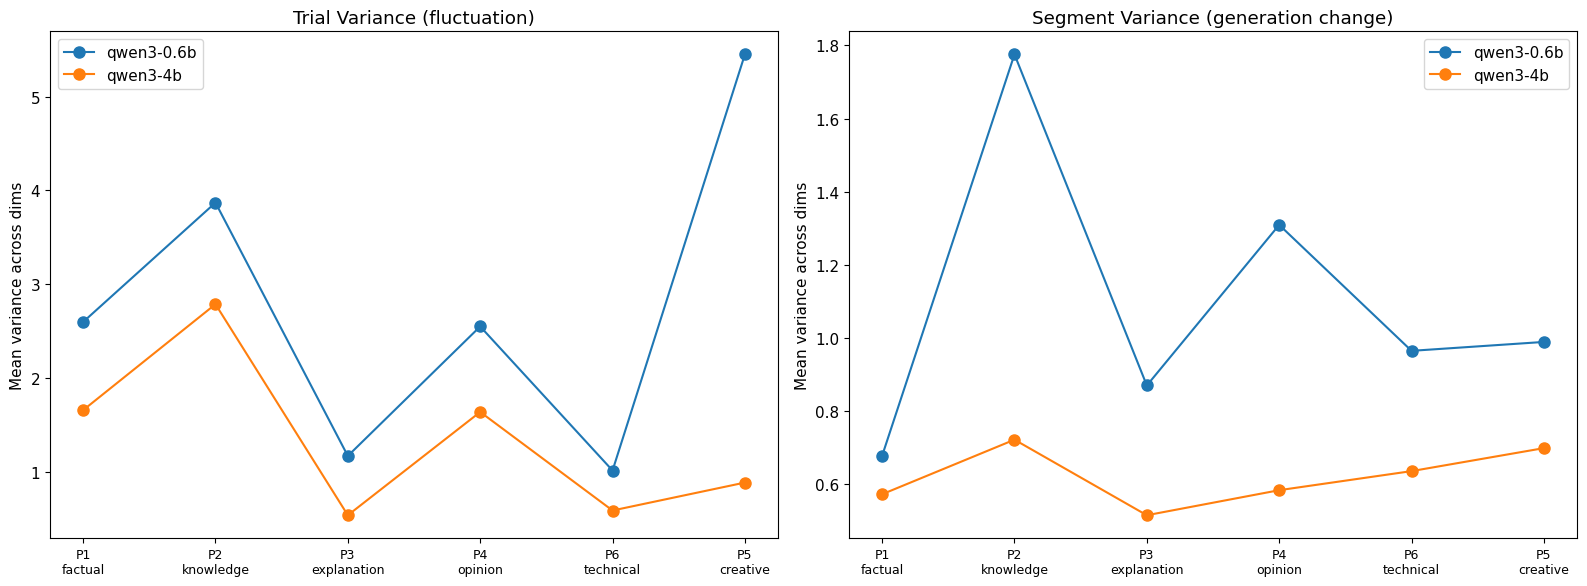


Trial variance (fluctuation) — higher = more uncertain:
  P1 (factual     ) qwen3-0.6b     : trial_var=2.5982, seg_var=0.6772
  P1 (factual     ) qwen3-4b       : trial_var=1.6585, seg_var=0.5721
  P2 (knowledge   ) qwen3-0.6b     : trial_var=3.8700, seg_var=1.7755
  P2 (knowledge   ) qwen3-4b       : trial_var=2.7877, seg_var=0.7214
  P3 (explanation ) qwen3-0.6b     : trial_var=1.1707, seg_var=0.8697
  P3 (explanation ) qwen3-4b       : trial_var=0.5387, seg_var=0.5147
  P4 (opinion     ) qwen3-0.6b     : trial_var=2.5505, seg_var=1.3091
  P4 (opinion     ) qwen3-4b       : trial_var=1.6393, seg_var=0.5832
  P5 (creative    ) qwen3-0.6b     : trial_var=5.4500, seg_var=0.9888
  P5 (creative    ) qwen3-4b       : trial_var=0.8869, seg_var=0.6983
  P6 (technical   ) qwen3-0.6b     : trial_var=1.0153, seg_var=0.9645
  P6 (technical   ) qwen3-4b       : trial_var=0.5892, seg_var=0.6354


In [3]:
# === Cell 3: Part A — Trial間揺らぎとSegment間変化 ===
# 各プロンプト×モデルで:
#   trial_var: 同一segmentの10 trial間の平均分散 → 「揺らぎ」
#   seg_var:   同一trialの10 segment間の平均分散 → 「生成過程の変化」

fluctuation = []
for pid in PROMPTS:
    for mid in MODELS:
        if (pid, mid) not in data:
            continue
        df = data[(pid, mid)]
        X = df.drop(columns=DROP_COLS).values
        trials = df['trial_id'].values
        segs = df['segment_index'].values

        # Trial間分散: 各segment位置で10 trialのhidden stateの分散
        trial_vars = []
        for s in sorted(set(segs)):
            mask = segs == s
            if mask.sum() > 1:
                trial_vars.append(X[mask].var(axis=0).mean())

        # Segment間分散: 各trialで10 segmentのhidden stateの分散
        seg_vars = []
        for t in sorted(set(trials)):
            mask = trials == t
            if mask.sum() > 1:
                seg_vars.append(X[mask].var(axis=0).mean())

        fluctuation.append({
            'pid': pid, 'mid': mid,
            'category': PROMPTS[pid]['category'],
            'trial_var': np.mean(trial_vars),
            'seg_var': np.mean(seg_vars),
        })

df_fluct = pd.DataFrame(fluctuation)

# 可視化: カテゴリ別のtrial_var と seg_var
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_model = {'qwen3-0.6b': 'tab:blue', 'qwen3-4b': 'tab:orange'}
pid_order = ['P1', 'P2', 'P3', 'P4', 'P6', 'P5']  # factual → creative

for mid in MODELS:
    mask = df_fluct['mid'] == mid
    df_m = df_fluct[mask].set_index('pid').loc[pid_order]
    x = range(len(pid_order))
    axes[0].plot(x, df_m['trial_var'], 'o-', color=colors_model[mid],
                 label=mid, markersize=8)
    axes[1].plot(x, df_m['seg_var'], 'o-', color=colors_model[mid],
                 label=mid, markersize=8)

labels = [f'{p}\n{PROMPTS[p]["category"]}' for p in pid_order]
for ax, title in zip(axes, ['Trial Variance (fluctuation)', 'Segment Variance (generation change)']):
    ax.set_xticks(range(len(pid_order)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(title)
    ax.legend()
    ax.set_ylabel('Mean variance across dims')

plt.tight_layout()
os.makedirs('results/comprehensive', exist_ok=True)
plt.savefig('results/comprehensive/prompt_fluctuation.png', dpi=150)
plt.show()

print('\nTrial variance (fluctuation) — higher = more uncertain:')
for _, row in df_fluct.iterrows():
    print(f'  {row["pid"]} ({row["category"]:12s}) {row["mid"]:15s}: '
          f'trial_var={row["trial_var"]:.4f}, seg_var={row["seg_var"]:.4f}')

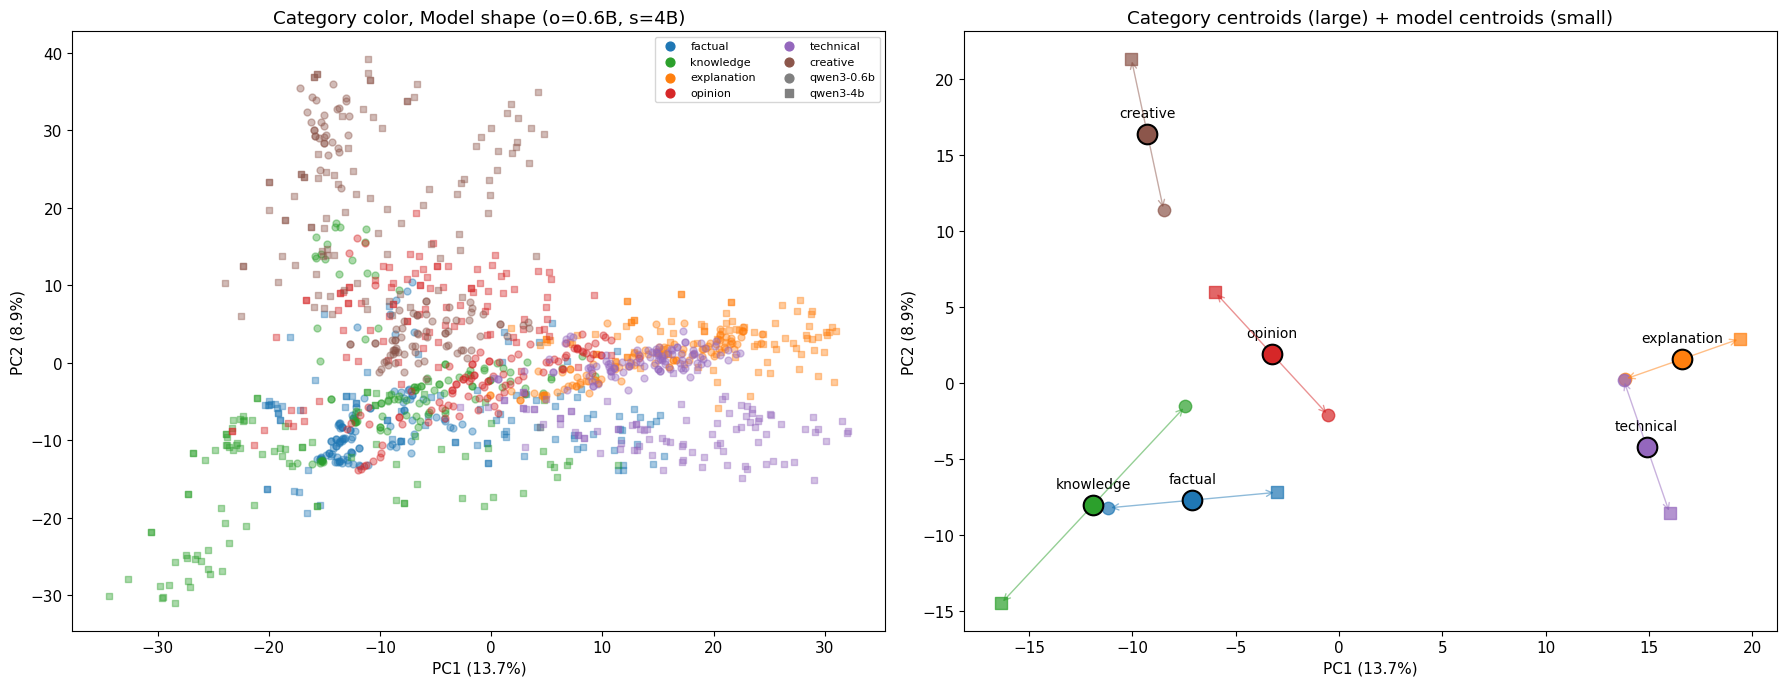

In [4]:
# === Cell 4: Part A — PCA空間でのプロンプト構造 ===
# 全12データセットを結合してPCA

N_COMMON = 64

# 各モデル別にPCA→64d
model_reduced = {}
model_prompts = {}
for mid in MODELS:
    frames, plabels = [], []
    for pid in PROMPTS:
        if (pid, mid) in data:
            X = data[(pid, mid)].drop(columns=DROP_COLS).values
            frames.append(X)
            plabels.extend([pid] * len(X))
    X_all = np.vstack(frames)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_all)
    pca = PCA(n_components=N_COMMON)
    X_r = pca.fit_transform(X_scaled)
    model_reduced[mid] = X_r
    model_prompts[mid] = np.array(plabels)

# 結合→2D
model_ids_list = list(MODELS.keys())
X_combined = np.vstack([model_reduced[mid] for mid in model_ids_list])
model_labels = np.concatenate([np.full(len(model_reduced[mid]), mid) for mid in model_ids_list])
prompt_labels = np.concatenate([model_prompts[mid] for mid in model_ids_list])
category_labels = np.array([PROMPTS[p]['category'] for p in prompt_labels])

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_combined)
vr = pca_2d.explained_variance_ratio_

# カテゴリ別の散布図
colors_cat = {
    'factual': '#1f77b4', 'knowledge': '#2ca02c', 'explanation': '#ff7f0e',
    'opinion': '#d62728', 'technical': '#9467bd', 'creative': '#8c564b'
}
markers_model = {'qwen3-0.6b': 'o', 'qwen3-4b': 's'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# (A) Category color, model shape
for cat in CATEGORY_ORDER:
    for mid in model_ids_list:
        mask = (category_labels == cat) & (model_labels == mid)
        if mask.sum() > 0:
            axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], c=colors_cat[cat],
                            marker=markers_model[mid], alpha=0.4, s=25,
                            label=f'{cat} ({mid[:6]})')
axes[0].set_title('Category color, Model shape (o=0.6B, s=4B)')
axes[0].set_xlabel(f'PC1 ({vr[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({vr[1]:.1%})')
# Simplified legend
handles = [plt.scatter([], [], c=colors_cat[c], s=40, label=c) for c in CATEGORY_ORDER]
handles += [plt.scatter([], [], c='gray', marker=m, s=40, label=n)
            for n, m in markers_model.items()]
axes[0].legend(handles=handles, fontsize=8, ncol=2)

# (B) カテゴリ重心の配置
for cat in CATEGORY_ORDER:
    mask = category_labels == cat
    center = X_2d[mask].mean(axis=0)
    axes[1].scatter(center[0], center[1], c=colors_cat[cat], s=200,
                    edgecolors='black', linewidths=1.5, zorder=5)
    axes[1].annotate(cat, xy=center, fontsize=10, ha='center', va='bottom',
                     xytext=(0, 10), textcoords='offset points')
    # モデル別重心
    for mid in model_ids_list:
        mask_m = (category_labels == cat) & (model_labels == mid)
        if mask_m.sum() > 0:
            c_m = X_2d[mask_m].mean(axis=0)
            axes[1].scatter(c_m[0], c_m[1], c=colors_cat[cat],
                            marker=markers_model[mid], s=80, alpha=0.7)
            axes[1].annotate('', xy=c_m, xytext=center,
                             arrowprops=dict(arrowstyle='->', color=colors_cat[cat], alpha=0.5))

axes[1].set_title('Category centroids (large) + model centroids (small)')
axes[1].set_xlabel(f'PC1 ({vr[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({vr[1]:.1%})')

plt.tight_layout()
plt.savefig('results/comprehensive/prompt_category_pca.png', dpi=150)
plt.show()

---
# Part B: 層別比較 — 浅い層→深い層でのモデル間差異

**問い**: 深い層ほどモデル間の「考え方」の差が大きくなるか？

**データ**: P3 (Photosynthesis) の層別実験
- Qwen3-0.6B: layer 0, 7, 14, 21, -1(=27)
- Qwen3-4B: layer 0, 9, 18, 27, -1(=35)

**指標**: 各層でのモデル間距離比 (inter/intra)

In [5]:
# === Cell 5: Part B — 層別データ読み込み ===
layer_data = {}  # {(model_id, layer): DataFrame}

# 層別実験データ
for mid, layers in [('qwen3-0.6b', [0, 7, 14, 21]), ('qwen3-4b', [0, 9, 18, 27])]:
    for layer in layers:
        path = os.path.join(LAYER_DIR, f'P3_{mid}_layer{layer}', 'segments.csv.gz')
        if os.path.exists(path):
            layer_data[(mid, layer)] = pd.read_csv(path, compression='gzip')
            print(f'{mid} layer {layer}: {layer_data[(mid, layer)].shape}')

# ベースライン（最終層）はphase0_baselineから
for mid, n_layers in [('qwen3-0.6b', 28), ('qwen3-4b', 36)]:
    path = os.path.join(BASELINE_DIR, f'P3_{mid}', 'segments.csv.gz')
    if os.path.exists(path):
        last_layer = n_layers - 1
        layer_data[(mid, last_layer)] = pd.read_csv(path, compression='gzip')
        print(f'{mid} layer {last_layer} (final): {layer_data[(mid, last_layer)].shape}')

print(f'\nLoaded: {len(layer_data)} layer datasets')

qwen3-0.6b layer 0: (100, 1027)
qwen3-0.6b layer 7: (100, 1027)
qwen3-0.6b layer 14: (100, 1027)
qwen3-0.6b layer 21: (100, 1027)
qwen3-4b layer 0: (100, 2563)
qwen3-4b layer 9: (100, 2563)
qwen3-4b layer 18: (100, 2563)
qwen3-4b layer 27: (100, 2563)
qwen3-0.6b layer 27 (final): (100, 1027)
qwen3-4b layer 35 (final): (100, 2563)

Loaded: 10 layer datasets


Depth 0%     (L0/0): sil=0.1145, ratio=0.00
Depth 25%    (L7/9): sil=0.0461, ratio=0.00
Depth 50%    (L14/18): sil=0.0496, ratio=0.00
Depth 75%    (L21/27): sil=0.0598, ratio=0.00
Depth Final  (L27/35): sil=0.0402, ratio=0.00


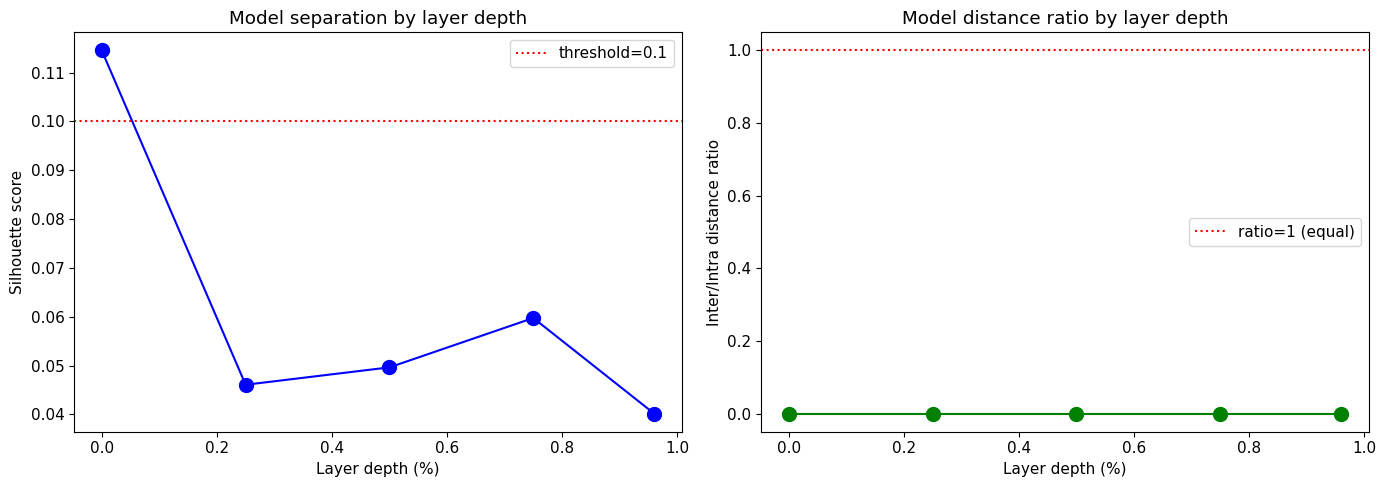

In [6]:
# === Cell 6: Part B — 層別モデル間距離比較 ===
# 各層の深さ（%）を正規化して比較
# 0.6B: 0/28=0%, 7/28=25%, 14/28=50%, 21/28=75%, 27/28=96%
# 4B:   0/36=0%, 9/36=25%, 18/36=50%, 27/36=75%, 35/36=97%

layer_info = {
    'qwen3-0.6b': [(0, 0.0), (7, 0.25), (14, 0.50), (21, 0.75), (27, 0.96)],
    'qwen3-4b':   [(0, 0.0), (9, 0.25), (18, 0.50), (27, 0.75), (35, 0.97)],
}

# 各モデル各層のPCA→64d、その後ペアワイズ比較
# 同一深さ%のペアで距離を計算
depth_pcts = [0.0, 0.25, 0.50, 0.75, 0.96]  # 共通の深さ
depth_labels = ['0%', '25%', '50%', '75%', 'Final']

results_layer = []
for depth_idx, depth in enumerate(depth_pcts):
    # この深さに対応するlayerを取得
    layer_06 = layer_info['qwen3-0.6b'][depth_idx][0]
    layer_4b = layer_info['qwen3-4b'][depth_idx][0]

    if (('qwen3-0.6b', layer_06) not in layer_data or
        ('qwen3-4b', layer_4b) not in layer_data):
        continue

    X_06 = layer_data[('qwen3-0.6b', layer_06)].drop(columns=DROP_COLS).values
    X_4b = layer_data[('qwen3-4b', layer_4b)].drop(columns=DROP_COLS).values

    # 個別PCA→64d→結合→PCA→2D
    pca_06 = PCA(n_components=min(64, min(X_06.shape)))
    pca_4b = PCA(n_components=min(64, min(X_4b.shape)))
    R_06 = pca_06.fit_transform(StandardScaler().fit_transform(X_06))
    R_4b = pca_4b.fit_transform(StandardScaler().fit_transform(X_4b))

    # 次元を揃える
    n_dim = min(R_06.shape[1], R_4b.shape[1])
    R_06 = R_06[:, :n_dim]
    R_4b = R_4b[:, :n_dim]

    X_cat = np.vstack([R_06, R_4b])
    labels = np.array([0]*len(R_06) + [1]*len(R_4b))

    pca_vis = PCA(n_components=2)
    X_vis = pca_vis.fit_transform(X_cat)

    # Silhouette
    sil = silhouette_score(X_vis, labels)

    # Inter/intra distance ratio
    center_06 = X_vis[:len(R_06)].mean(axis=0)
    center_4b = X_vis[len(R_06):].mean(axis=0)
    inter = np.linalg.norm(center_06 - center_4b)
    intra_06 = np.mean(np.linalg.norm(X_vis[:len(R_06)] - center_06, axis=1))
    intra_4b = np.mean(np.linalg.norm(X_vis[len(R_06):] - center_4b, axis=1))
    ratio = inter / (0.5 * (intra_06 + intra_4b) + 1e-8)

    results_layer.append({
        'depth': depth, 'depth_label': depth_labels[depth_idx],
        'layer_06': layer_06, 'layer_4b': layer_4b,
        'silhouette': sil, 'inter_dist': inter,
        'intra_avg': 0.5*(intra_06+intra_4b), 'ratio': ratio,
        'X_vis': X_vis, 'labels': labels,
    })
    print(f'Depth {depth_labels[depth_idx]:6s} (L{layer_06}/{layer_4b}): '
          f'sil={sil:.4f}, ratio={ratio:.2f}')

# 可視化: 深さ vs silhouette / ratio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
depths = [r['depth'] for r in results_layer]
sils = [r['silhouette'] for r in results_layer]
ratios = [r['ratio'] for r in results_layer]

axes[0].plot(depths, sils, 'bo-', markersize=10)
axes[0].axhline(0.1, color='red', linestyle=':', label='threshold=0.1')
axes[0].set_xlabel('Layer depth (%)')
axes[0].set_ylabel('Silhouette score')
axes[0].set_title('Model separation by layer depth')
axes[0].legend()

axes[1].plot(depths, ratios, 'go-', markersize=10)
axes[1].axhline(1.0, color='red', linestyle=':', label='ratio=1 (equal)')
axes[1].set_xlabel('Layer depth (%)')
axes[1].set_ylabel('Inter/Intra distance ratio')
axes[1].set_title('Model distance ratio by layer depth')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/comprehensive/layer_depth_comparison.png', dpi=150)
plt.show()

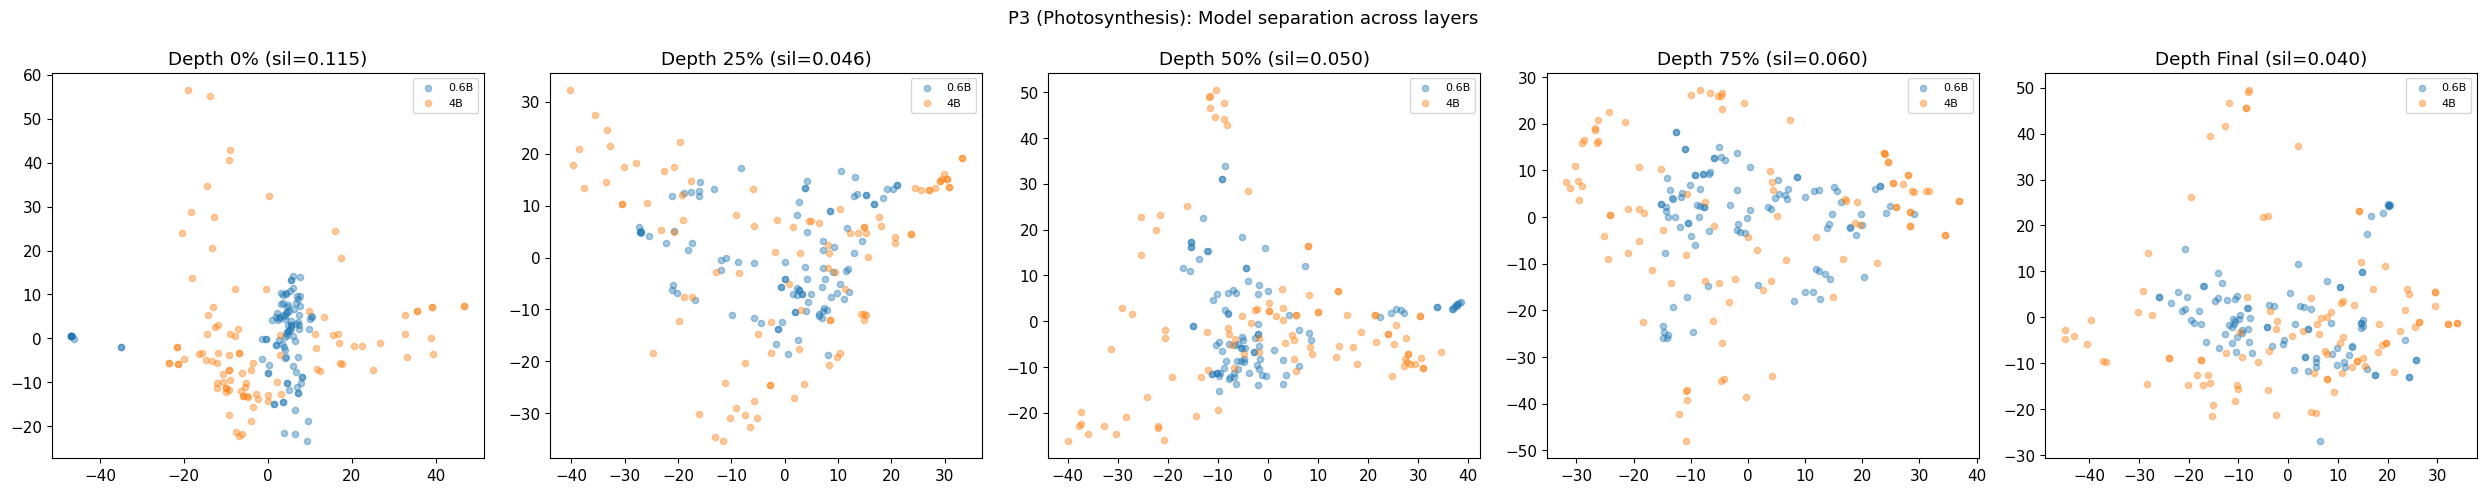

In [7]:
# === Cell 7: Part B — 層別PCA散布図 ===
n_layers = len(results_layer)
fig, axes = plt.subplots(1, n_layers, figsize=(5*n_layers, 5))
if n_layers == 1:
    axes = [axes]

for i, r in enumerate(results_layer):
    ax = axes[i]
    mask_06 = r['labels'] == 0
    mask_4b = r['labels'] == 1
    ax.scatter(r['X_vis'][mask_06, 0], r['X_vis'][mask_06, 1],
               c='tab:blue', alpha=0.4, s=20, label='0.6B')
    ax.scatter(r['X_vis'][mask_4b, 0], r['X_vis'][mask_4b, 1],
               c='tab:orange', alpha=0.4, s=20, label='4B')
    ax.set_title(f'Depth {r["depth_label"]} (sil={r["silhouette"]:.3f})')
    ax.legend(fontsize=8)

plt.suptitle('P3 (Photosynthesis): Model separation across layers', fontsize=13)
plt.tight_layout()
plt.savefig('results/comprehensive/layer_pca_scatter.png', dpi=150)
plt.show()

---
# Part C: 混成Debate設計

Part A/Bの結果を踏まえ、0.6B + 4B混成debateの仕様を確定する。

**設計方針**:
- Agent 0, 1: Qwen3-0.6B
- Agent 2: Qwen3-4B
- プロンプト: 説明系（P3/P6的な問題）
- Hidden state抽出: Part Bで最も分離する層

**実装**: llm-hidden-state-platformのAPIを使い、debate形式のプロンプトで順次抽出

In [8]:
# === Cell 8: Part C — 最適層と最適プロンプトの選定 ===
import json

# Part Aからプロンプト別のモデル間距離比を再計算
prompt_ratios = {}
for pid in PROMPTS:
    mask_06 = (model_labels == 'qwen3-0.6b') & (prompt_labels == pid)
    mask_4b = (model_labels == 'qwen3-4b') & (prompt_labels == pid)
    if mask_06.sum() > 0 and mask_4b.sum() > 0:
        c_06 = X_2d[mask_06].mean(axis=0)
        c_4b = X_2d[mask_4b].mean(axis=0)
        inter = np.linalg.norm(c_06 - c_4b)
        intra_06 = np.mean(np.linalg.norm(X_2d[mask_06] - c_06, axis=1))
        intra_4b = np.mean(np.linalg.norm(X_2d[mask_4b] - c_4b, axis=1))
        prompt_ratios[pid] = inter / (0.5*(intra_06+intra_4b) + 1e-8)

# 最適プロンプトカテゴリ
best_prompts = sorted(prompt_ratios.items(), key=lambda x: -x[1])
print('=== Prompt ranking by model separation ===')
for pid, ratio in best_prompts:
    print(f'  {pid} ({PROMPTS[pid]["category"]:12s}): ratio={ratio:.2f}')

# 最適層
if results_layer:
    best_layer = max(results_layer, key=lambda x: x['silhouette'])
    print(f'\n=== Best layer for model separation ===')
    print(f'  Depth {best_layer["depth_label"]} '
          f'(0.6B: layer {best_layer["layer_06"]}, 4B: layer {best_layer["layer_4b"]})')
    print(f'  silhouette={best_layer["silhouette"]:.4f}, ratio={best_layer["ratio"]:.2f}')

print(f'\n=== Mixed Debate Design ===')
print(f'Agents: Qwen3-0.6B x2 + Qwen3-4B x1')
print(f'Best prompt type: {best_prompts[0][0]} ({PROMPTS[best_prompts[0][0]]["category"]})')
if results_layer:
    print(f'Best layer: depth {best_layer["depth_label"]} '
          f'(0.6B=L{best_layer["layer_06"]}, 4B=L{best_layer["layer_4b"]})')
print(f'Expected benefit: model identity creates genuine private thoughts')

# 全結果保存
summary = {
    'part_a': {
        'prompt_ratios': {k: float(v) for k, v in prompt_ratios.items()},
        'prompt_stats': prompt_stats,
        'fluctuation': [{k: v for k, v in f.items()} for f in fluctuation],
    },
    'part_b': {
        'layer_results': [{
            'depth': r['depth'], 'depth_label': r['depth_label'],
            'layer_06': r['layer_06'], 'layer_4b': r['layer_4b'],
            'silhouette': float(r['silhouette']),
            'ratio': float(r['ratio']),
        } for r in results_layer],
    },
    'part_c': {
        'best_prompt': best_prompts[0][0] if best_prompts else None,
        'best_layer_06': best_layer['layer_06'] if results_layer else None,
        'best_layer_4b': best_layer['layer_4b'] if results_layer else None,
    }
}
with open('results/comprehensive/09_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(f'\nSaved: results/comprehensive/09_summary.json')

=== Prompt ranking by model separation ===
  P2 (knowledge   ): ratio=1.50
  P6 (technical   ): ratio=1.48
  P4 (opinion     ): ratio=1.26
  P1 (factual     ): ratio=1.00
  P3 (explanation ): ratio=0.93
  P5 (creative    ): ratio=0.85

=== Best layer for model separation ===
  Depth 0% (0.6B: layer 0, 4B: layer 0)
  silhouette=0.1145, ratio=0.00

=== Mixed Debate Design ===
Agents: Qwen3-0.6B x2 + Qwen3-4B x1
Best prompt type: P2 (knowledge)
Best layer: depth 0% (0.6B=L0, 4B=L0)
Expected benefit: model identity creates genuine private thoughts

Saved: results/comprehensive/09_summary.json
